# **Computer Vision H.W. #2**
---
___
# *Student ID and Names: -*

b00094286 ---- Mohamed Abdelrahim Alawadhi

b00097405 ---- Arya Sankhe
___

# HW2
**Instructions:**

- Solve the following coding problems using Python and OpenCV.
- Submit the code along with **explanations of each step**.
- Your solutions will be graded based on correctness, efficiency, and clarity of your code and explanation.

## Question 1: Canny Edge Detection with Dynamic Thresholds (8 Marks)
Instead of using static threshold values for Canny edge detection, implement a function that dynamically adjusts the thresholds based on the standard deviation of the pixel intensity values in the image.

Steps to follow:

- Compute the mean and standard deviation of pixel intensities in the grayscale image.
- Use these values to determine the lower and upper thresholds for the Canny function. You can use the following rules:
    - `Lower threshold = Mean - (k * Standard Deviation)`
    - `Upper threshold = Mean + (k * Standard Deviation)` Where k is a parameter that can be adjusted.
- Apply Canny edge detection using these thresholds.
- Write a different function that will apply only the Sobel operator **(You are not allowed to use the Sobel predefined function)**
- Display the original image, sobel image and the edge-detected image side by side.
- Use the `car.jpg` image to test your function
- You need to show the output of your function with different `k` values and explain the effect of changing this parameter

In [ ]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
def canny_edge_detection(img, k):
  # Calculations of the mean and standard deviation
  mean = np.mean(img)
  std = np.std(img)

  # Calculations of the lower and upper thresholds
  lower_thres = mean - (k * std)
  upper_thres = mean + (k * std)

  edges = cv.Canny(img, lower_thres, upper_thres)

  return edges

In [ ]:
def sobel_edge_detection(img):
  # The filters/kernels for x and y
  fx = np.array([[-1,0,1],
                 [-2,0,2],
                 [-1,0,1]])

  fy = np.array([[-1,-2,-1],
                 [0,0,0],
                 [1,2,1]])

  # Applying the Sobel filters
  edgesx = cv.filter2D(img, cv.CV_32F, fx)
  edgesy = cv.filter2D(img, cv.CV_32F, fy)

  # Calculating the gradient magnitude
  mag = np.sqrt(edgesx**2 + edgesy**2).astype(np.uint)

  return mag


(-0.5, 1559.5, 1039.5, -0.5)

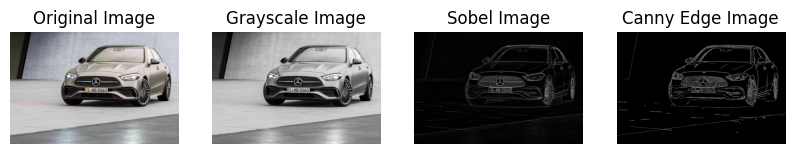

In [ ]:
# Reading and printing the original image
img = cv.imread("/content/car.jpg", cv.IMREAD_COLOR)

plt.figure(figsize = (10,10))

plt.subplot(1,4,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

# Converting the original image to grayscale and printing it out
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.subplot(1,4,2)
plt.title("Grayscale Image")
plt.imshow(img_gray, cmap = "gray")
plt.axis("off")

# Calling the Sobel function and printing it out
sobel_img = sobel_edge_detection(img_gray)

plt.subplot(1,4,3)
plt.title("Sobel Image")
plt.imshow(sobel_img, cmap = "gray")
plt.axis("off")

# Assigning "k" a value, calling the canny function and printing it out
k = 1
canny_img = canny_edge_detection(img_gray, k)

plt.subplot(1,4,4)
plt.title("Canny Edge Image")
plt.imshow(canny_img, cmap = "gray")
plt.axis("off")


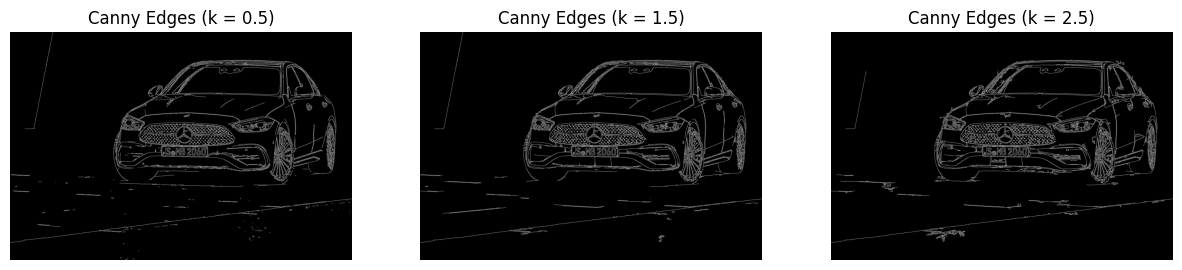

In [ ]:
# Lets create an array of different values for "k" to test the canny function
k_array = [0.5, 1.5, 2.5]

plt.figure(figsize = (15,15))

# Using a loop to print out the results of the canny function for different "k" values
for i, k in enumerate(k_array):
  canny_img = canny_edge_detection(img_gray, k)

  plt.subplot(1,3,i+1)
  plt.title(f"Canny Edges (k = {k})")
  plt.imshow(canny_img, cmap = "gray")
  plt.axis("off")

**Description of images**
---
***k = 0.5***
*   Having a k value will result in a wide range of edges being detected (which includes the weaker edges as well). Thus, it detects more edges, but with result in more false edges.

***k = 1.5***
*   A more balanced image is produced, since it detects more significant edges and reduces the noise in the image.

***k = 2.5***
*   It detects more stronger edges (the image becomes more "cleaner"), but it starts to miss some finer details.


**Summary**
---
*  Basically, the k value affect the thresholds for the canny edge detection.

*   The smaller the k, the more it will detect edges (weak and strong edges).

*   The higher the k value, the more it will detect stronger/significant edges, but at the cost of losing other smaller details.







## Question 2: Harris Corner Detector with Gaussian Smoothing (6 Marks)
Modify the traditional Harris corner detector to incorporate a Gaussian smoothing step before applying the corner detection. Compare the results with and without Gaussian smoothing.

Steps to follow:

- Apply Gaussian blur to the grayscale image before using the Harris corner detector.
- Apply the Harris corner detector to the smoothed image and the original image.
- Mark the corners detected on both images.
- Display both images side by side, with the corners clearly marked.
- Use the `corners.png` image to test your function

(-0.5, 999.5, 999.5, -0.5)

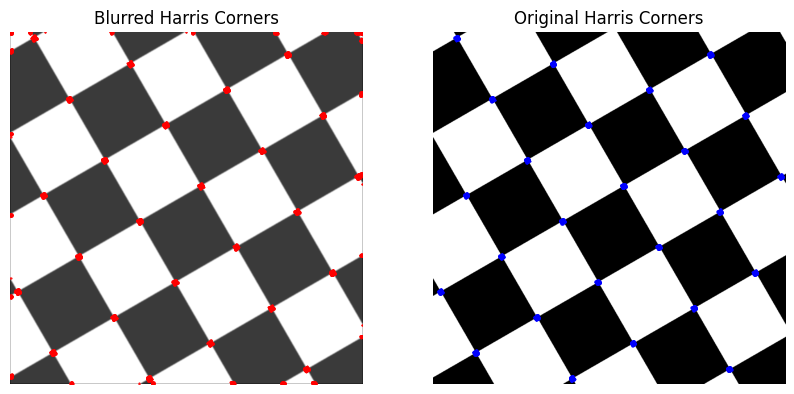

In [ ]:
img = cv.imread("/content/corners.png", cv.IMREAD_GRAYSCALE)

# Appltying the Guassian Blur to the image
blur_img = cv.GaussianBlur(img, ksize = (5,5), sigmaX = 2, sigmaY = 2, borderType = cv.BORDER_CONSTANT)

# Applying the Harris Corner Detector to both of the blurred and original images
blur_harris_img = cv.cornerHarris(blur_img, blockSize = 9, ksize = 5, k = 0.04)
harris_img = cv.cornerHarris(img, blockSize = 9, ksize = 5, k = 0.04)

# The thresholds to mark corners for both of the images
blur_threshold = 0.05 * blur_harris_img.max()
harris_threshold = 0.05 * harris_img.max()

# Creating the corner masks for both images
blur_corner_mask = (blur_harris_img > blur_threshold).astype(np.uint8) * 255
harris_corner_mask = (harris_img > harris_threshold).astype(np.uint8) * 255

# Getting the coordinates for both images
blur_coordinates = np.where(blur_corner_mask > 0)
harris_coordinates = np.where(harris_corner_mask > 0)

plt.figure(figsize=(10,10))

# Plotting the blurred image with the corners marked
plt.subplot(1,2,1)
plt.imshow(blur_img, cmap = "gray")
plt.scatter(blur_coordinates[1], blur_coordinates[0], color = "red", marker = ".", s = 1)
plt.title("Blurred Harris Corners")
plt.axis("off")

# Plotting the Original image with the corners marked
plt.subplot(1,2,2)
plt.imshow(img, cmap = "gray")
plt.scatter(harris_coordinates[1], harris_coordinates[0], color = "blue", marker = ".", s = 1)
plt.title("Original Harris Corners")
plt.axis("off")

**Conclusion**
---
The blurred image is able to detect more corners than the original image.

## Question 3: Laplacian of Gaussian Filter with Kernel Size Optimization (5 Marks)
Write a function that applies the Laplacian of Gaussian (LoG) filter on an image. The function should take a list of different kernel sizes as input, and return the edge-detected images for each kernel size. Display all the results in a grid layout for comparison.

Steps to follow:

- Apply the Gaussian blur followed by the Laplacian operator.
- Iterate over different kernel sizes and apply the filter.
- Display the original image and the results of each kernel size in a grid.
- Use the `cat.jpg` image to test your function

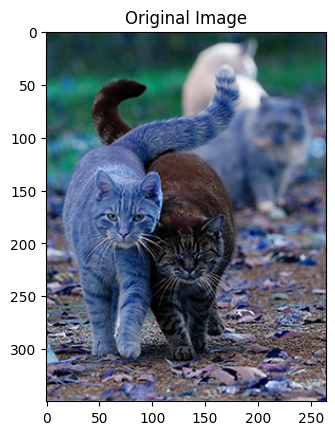

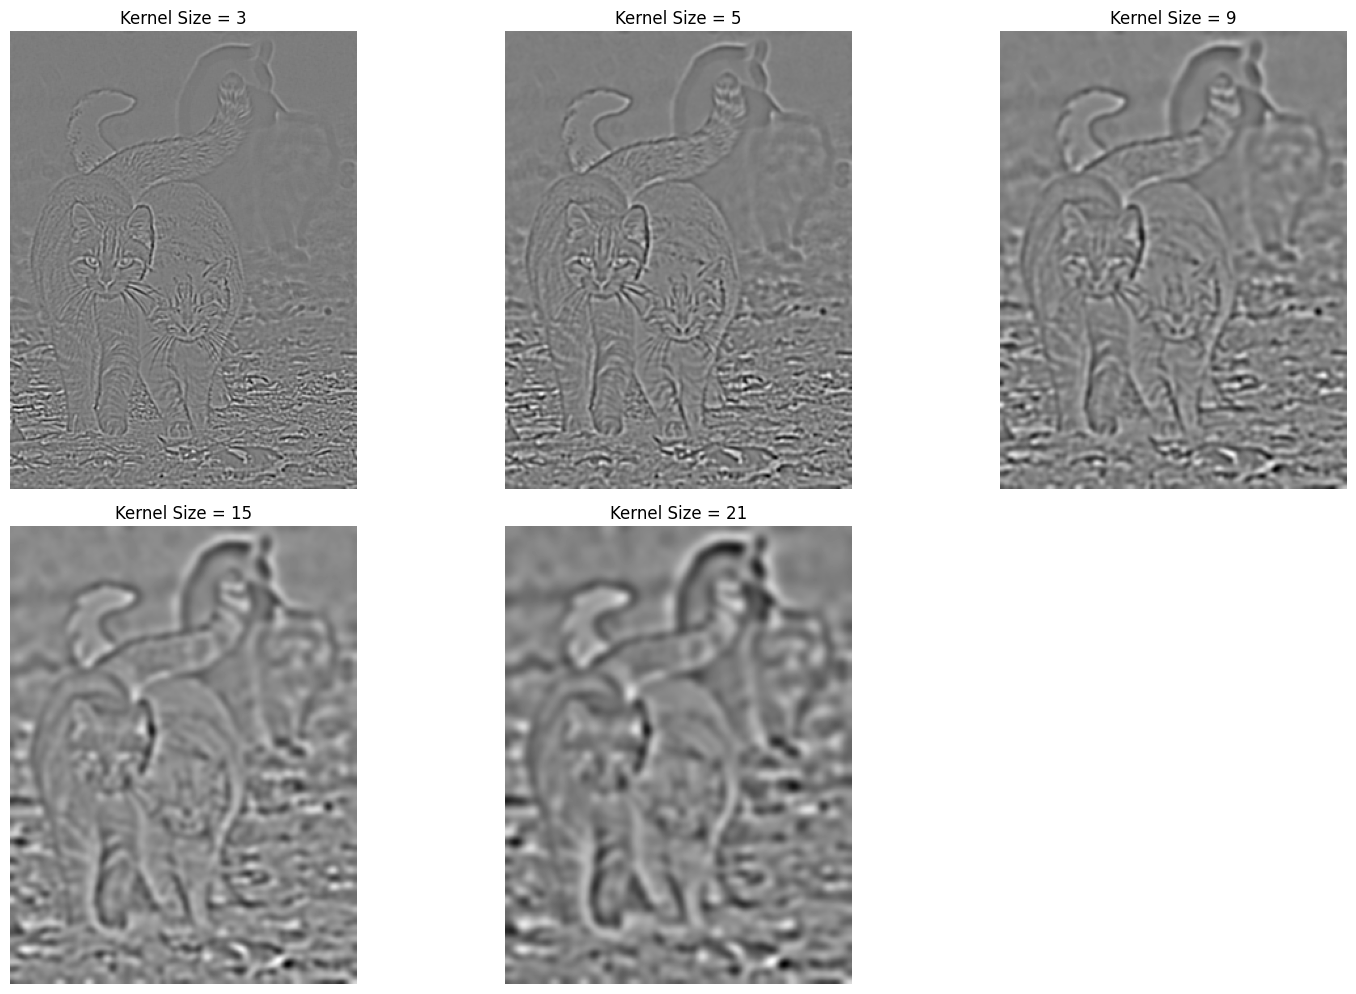

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the image
image_path = 'cat.jpg'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
imagecolor = cv2.imread(image_path, cv2.IMREAD_COLOR)


plt.title("Original Image")
plt.imshow(imagecolor)
# Define the range of kernel sizes to iterate over
kernel_sizes = [3, 5, 9, 15, 21]  # Adjust as needed

# Create a plot with subplots to display the results
num_kernels = len(kernel_sizes)
plt.figure(figsize=(15, 15))

# Iterate over different kernel sizes
for i, ksize in enumerate(kernel_sizes):
    # Apply Gaussian blur with the current kernel size
    blurred_image = cv2.GaussianBlur(image, (ksize, ksize), sigmaX=0, sigmaY=0)

    # Apply the Laplacian operator on the blurred image
    laplacian_image = cv2.Laplacian(blurred_image, cv2.CV_32F, ksize=ksize)

    response = laplacian_image

    # Display the original image and the Laplacian results for each kernel size
    plt.subplot(3, 3, i + 1)
    plt.imshow(response, cmap='gray')
    plt.title(f'Kernel Size = {ksize}')
    plt.axis('off')

# Show all the subplots
plt.tight_layout()
plt.show()


## Question 4: SIFT Descriptor Matching for Object Detection (6 Marks)
Using the SIFT descriptor, detect key points in two images and match the key points to identify similar regions between them. You may use OpenCV’s `BFMatcher` or `FLANN` for matching, and visualize the matching key points on the image.

Steps to follow:

- Extract SIFT descriptors from both images.
- Use a matching algorithm to find corresponding points between the two images.
- Display the images side by side with lines connecting matched key points.
- Use the `img1.jpg` and `img2.jpg` images to test your function

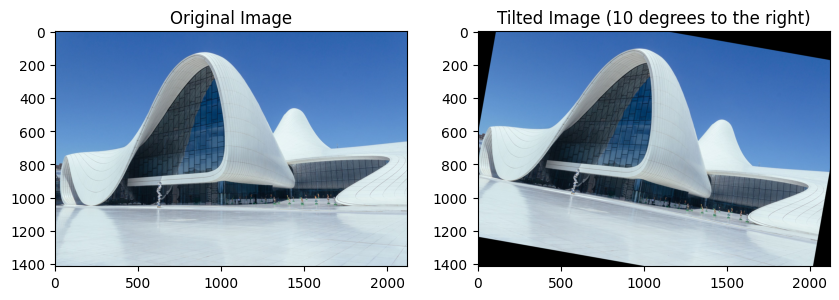

In [ ]:
# Let's rotate or transform the image to give it a forward-facing appearance or tilt it toward the right.

import cv2
import numpy as np
from matplotlib import pyplot as plt

def tilt_image(image, angle):
    # Get image dimensions
    (h, w) = image.shape[:2]

    # Set up rotation matrix with a point of rotation (center of the image)
    center = (w // 2, h // 2)

    # Apply rotation matrix to the image
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv2.warpAffine(image, matrix, (w, h))

    return rotated_image

# Load the newly uploaded image
image = cv2.imread('img2.jpg')

# Apply a tilt to the right by rotating the image by 10 degrees
tilted_image = tilt_image(image, -10)

# Display the original and tilted images
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')

# Tilted image
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(tilted_image, cv2.COLOR_BGR2RGB))
plt.title('Tilted Image (10 degrees to the right)')

plt.show()


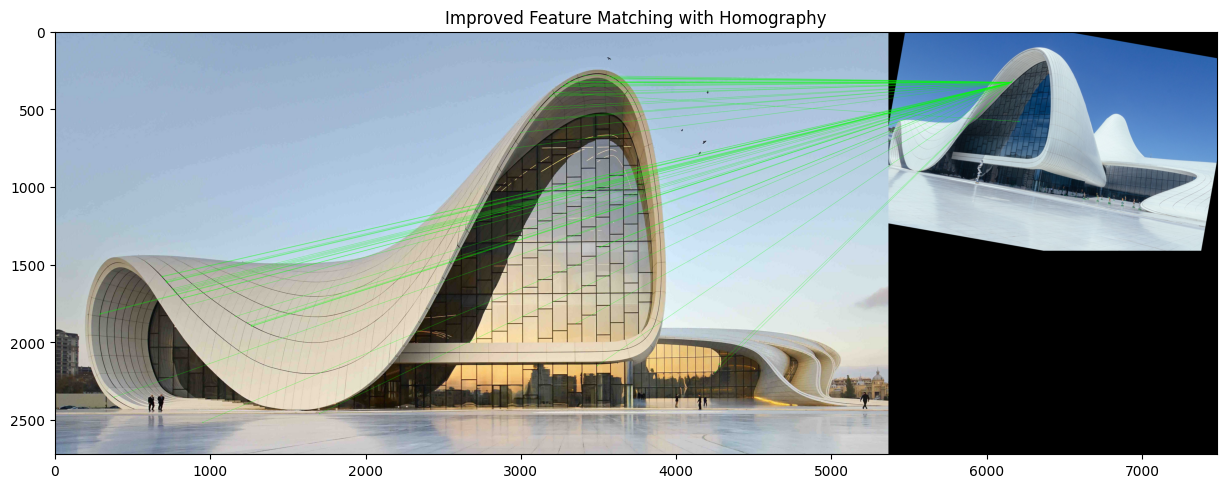

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


# Load the images
image1 = cv2.imread('img1.jpg')
image2 = cv2.imread('img2.jpg')


# Initialize the SIFT detector (can switch to ORB if required)
feat = cv2.SIFT_create()

# Find the keypoints and descriptors
kp1, des1 = feat.detectAndCompute(image1, None)
kp2, des2 = feat.detectAndCompute(image2, None)

# Create BFMatcher (Brute Force Matcher) with L2 norm for SIFT
bf = cv2.BFMatcher(cv2.NORM_L2)

# Match descriptors using knnMatch
matches = bf.knnMatch(des1, des2, k=2)

# Apply ratio test to filter good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

# Extract locations of matched keypoints
src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

# Use RANSAC to estimate homography matrix
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 4.0)

# Draw only inliers
matchesMask = mask.ravel().tolist()

# Improved drawing parameters
draw_params = dict(matchColor=(0, 255, 0),  # Matches in green
                   singlePointColor=None,
                   matchesMask=matchesMask,  # Only draw inliers
                   flags=2)

# Draw the matches
output_image = cv2.drawMatches(image1, kp1, tilted_image, kp2, good_matches, None, **draw_params)

# Display the result
plt.figure(figsize=(15, 15))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('Improved Feature Matching with Homography')
plt.show()
